### **Aplicação Unificada**

In [1]:
# Importando Bibliotecas
import sys
sys.path.append('../../')

import os
import json
import cv2 as cv
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Callable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms as T
from scipy.stats import pearsonr

import albumentations as A
from albumentations.pytorch import ToTensorV2

import optuna
import kornia

# Importando Modelos
from notebooks.playground_VC.unet.unet_regression import UNet

# Importar sua classe existente
from src.vfss_dataset5 import VFSSImageDataset
from src.data_extraction.video_frame import (create_video_frame_df,
                                             load_video_frame_metadata_from_csv)
from src.split_data import split_data_k_fold
from src.target.heatmap import generate_heatmap_from_points
from src.utils import (plot_image_with_mask,
                       get_script_relative_path,
                       get_project_root_directory,
                       get_corners_from_angle,
                       clahe,
                       modify_input,
                       load_points,
                       custom_collate_fn,
                       set_seed,
                       avalia_status_GPU,
                       resolve_dataframe_path)

# Importando classes/funções - Podar imports que não são chamados aqui.
from src.training.config import TrainingConfig
from src.training.checkpoint_manager import CheckpointManager
from src.training.loss import (LossCalculator,
                               FocalMSELoss,
                               FocalMSEMaskedLoss)
from src.training.train_epoch import train_one_epoch
from src.training.validate import validate
from src.training.train_fold import train_one_fold
from src.training.cross_validation import cross_validate
from src.training.hyperparameter_tuning import (objective_optuna,
                                                tune_hyperparameters)
from src.evalutation.evaluation import TestEvaluator
from src.evalutation.inference import evaluate_model_on_test

set_seed(42)

### **Configuração**

In [2]:
# Parametros Básicos Iniciais
epochs = 200
model = "unet"
model_name = f"{model}\\FocalMSEMaskedLoss_{str(epochs)}ep"
model_kwargs = {
    "in_channels": 3,
    "num_keypoints": 2,
}

# Configuração
config = TrainingConfig(
    learning_rate=3e-4,
    batch_size=4,
    epochs=epochs,
    criterion_roi = nn.BCEWithLogitsLoss(),
    criterion_heatmap= FocalMSEMaskedLoss(),
    patience=10,
    checkpoint_dir=f"data\\model_weights\\{model_name}",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# Caminhos Importantes
videos_dir = 'data\\videos\\' 
labels_dir = 'data\\rotulos\\anotacoes-tecgraf\\'
frames_dir = 'data\\frames'
augmentation_dir = 'data/frames_augmentation'
path_dataframe = "data/metadados/video_frame_metadata.csv"

root = get_project_root_directory()
path_dataframe = os.path.join(root, path_dataframe)
video_frame_df = pd.read_csv(path_dataframe)
video_frame_df = video_frame_df.apply(resolve_dataframe_path, axis = 1)

# Adicionando os pontos direto no dataframe, para não precisar ficar abrindo arquivos
video_frame_df["keypoints"] = video_frame_df["target_dir"].apply(load_points)

# Atributos da função VFSSImageDataset
sigma = 20
output_dim = (256, 256)
offline_augmentation = True

transform_augmentation_online = A.Compose([
        A.Resize(output_dim[0], output_dim[1]),
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 10.0), mean=0, p=0.5),   # Ruído Gaussiano
        ToTensorV2()
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_augmentation_offline = A.Compose([
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
        
        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano
        A.Resize(output_dim[0], output_dim[1])
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_puro = A.Compose([A.Resize(output_dim[0], output_dim[1]),
                       ToTensorV2()],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Aplicando a divisão dos Folds
print("\nSplit Dados")
list_df_folds, df_test = split_data_k_fold(video_frame_df, test_size=0.2, n_folds=5)

# Avaliando Status do Uso da GPU
avalia_status_GPU()



Split Dados
Folds all: 92
Test: 23
Overall Dataset - Videos: 234 | Patients: 115 | Frames: 973 (100.0%)
Training + Validation Set - Videos: 192 | Patients: 92 | Frames: 795 (81.7%)
Test Set - Videos: 42 | Patients: 23 | Frames: 178 (18.3%)

Fold 1 - Videos: 41 | Patients: 19 | Frames: 174 (17.9%)
Fold 2 - Videos: 56 | Patients: 19 | Frames: 230 (23.6%)
Fold 3 - Videos: 40 | Patients: 18 | Frames: 168 (17.3%)
Fold 4 - Videos: 26 | Patients: 18 | Frames: 108 (11.1%)
Fold 5 - Videos: 29 | Patients: 18 | Frames: 115 (11.8%)


,split_name,n_videos,n_patients,n_frames,percentage_of_initial_frames,video_ids
0,fold_1,41,19,174,0.178828,"[101, 102, 103, 104, 105, 106, 107, 108, 109, ..."
1,fold_2,56,19,230,0.236382,"[129, 130, 131, 132, 136, 137, 138, 139, 140, ..."
2,fold_3,40,18,168,0.172662,"[122, 123, 125, 126, 127, 128, 152, 153, 154, ..."
3,fold_4,26,18,108,0.110997,"[10, 113, 114, 115, 116, 117, 118, 119, 120, 1..."
4,fold_5,29,18,115,0.118191,"[192, 193, 194, 195, 196, 197, 198, 199, 200, ..."
5,test_set,42,23,178,0.182939,"[100, 11, 13, 142, 143, 144, 145, 146, 147, 14..."



VERIFICAÇÃO DE GPU
PyTorch version: 2.2.2+cu121
CUDA disponível: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 2080 Ti
Número de GPUs: 1



<class 'torch.Tensor'> <class 'list'> <class 'torch.Tensor'> <class 'torch.Tensor'>


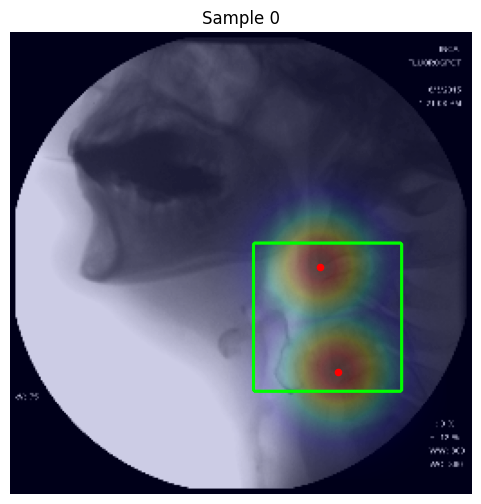

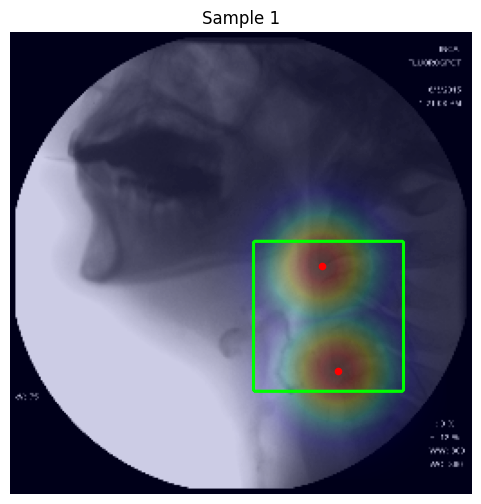

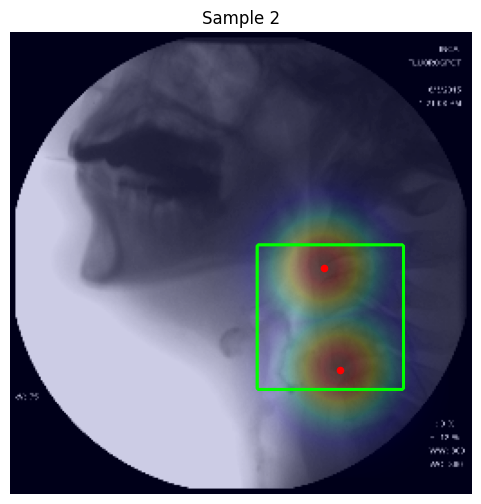

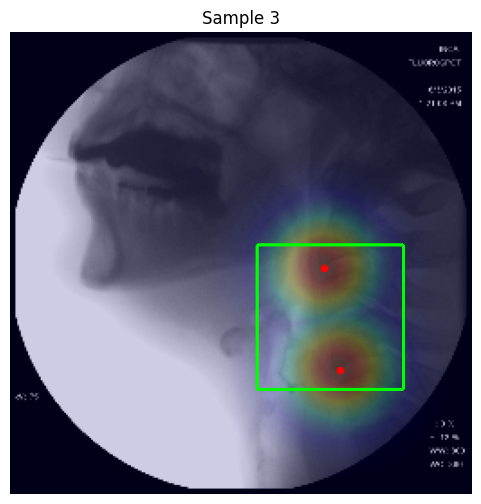

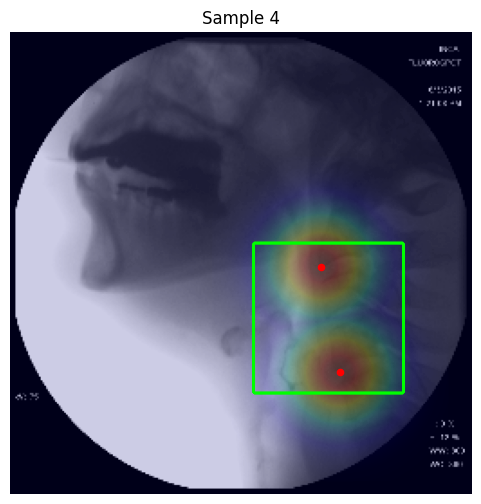

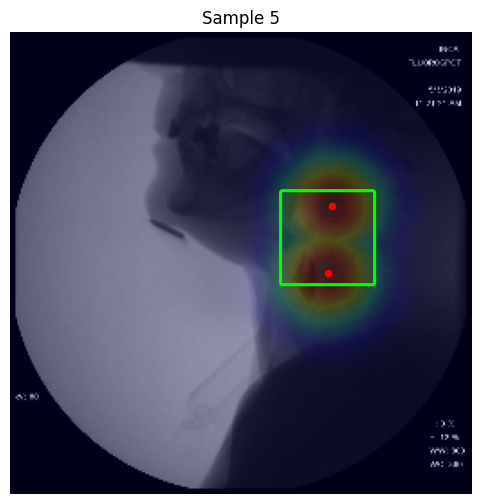

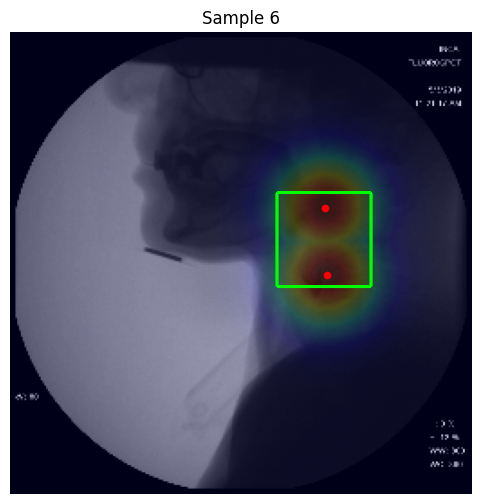

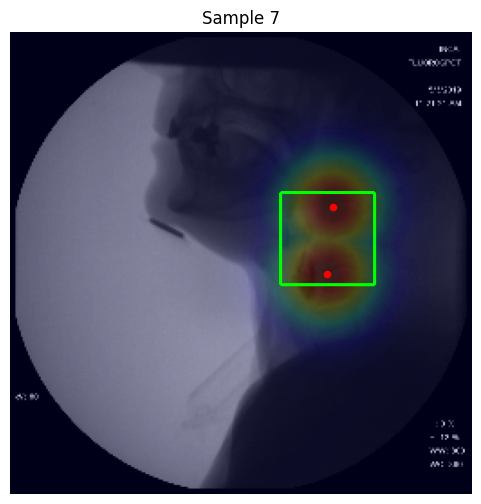

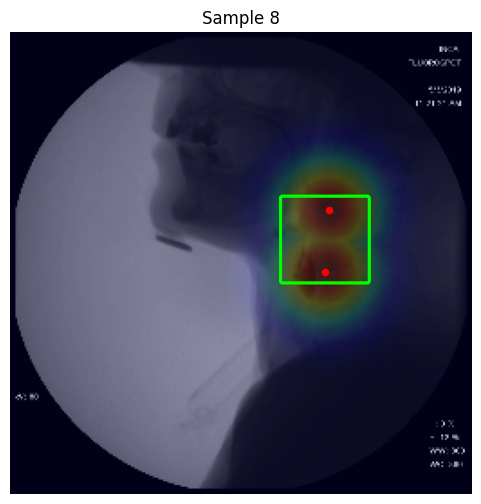

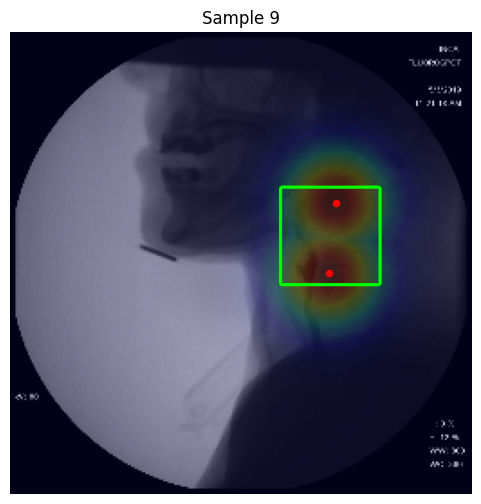

In [3]:
# Conjunto de Teste
test_dataset = VFSSImageDataset(
    video_frame_df = df_test,
    output_dim = output_dim,
    transform = transform_puro,      # Sempre sem augmentation para o Teste, então deve ser deterministico -> Resize + ToTensor
    offline_augmentation=False, # Sempre False para o teste
    sigma = sigma,
)

print(type(test_dataset[0][0]), type(test_dataset[0][1]), type(test_dataset[0][2]), type(test_dataset[0][3]))
for i in range(10):
    test_dataset.plot_sample(i, True, True, True)

### **Treino/Validação**

In [4]:
import time
import torch

# Conjunto de Teste
train_set = VFSSImageDataset(
    video_frame_df = df_test,
    output_dim = output_dim,
    transform = transform_puro,      # Sempre sem augmentation para o Teste, então deve ser deterministico
    offline_augmentation=False, # Sempre False para o teste
    sigma = sigma,
)

num_cores = min(8, os.cpu_count()//4 or 1)
print(num_cores)
train_loader = DataLoader(
            train_set, batch_size=config.batch_size, shuffle=True,
            collate_fn=custom_collate_fn, num_workers=num_cores, pin_memory=True, persistent_workers=True
        )


model = UNet(**model_kwargs)

model.to(config.device)
    
# Configuração
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = config.scheduler(
    optimizer,
    mode="min",
    factor=0.1,
    patience=config.patience // 3,  # Quando ver que o negócio tá ficando esquisito, mexe.
)


model.train()
# Pega apenas 1 batch do DataLoader
inputs, keypoints, heatmaps, roi = next(iter(train_loader))

# Manda pra GPU
inputs = inputs.to(config.device)
heatmaps = heatmaps.to(config.device)
roi = roi.to(config.device)

print("Iniciando Raio-X da GPU...\n")

# 1. Testando o Kornia (CLAHE)
torch.cuda.synchronize()
t0 = time.time()
inputs_mod = modify_input(inputs)
torch.cuda.synchronize()
t_kornia = time.time() - t0
print(f"Tempo do modify_input_fn (Kornia): {t_kornia:.4f} segundos")

# 2. Testando o Modelo (Forward Pass)
torch.cuda.synchronize()
t0 = time.time()
pred_roi, pred_heatmap = model(inputs_mod)
torch.cuda.synchronize()
t_model = time.time() - t0
print(f"Tempo do Modelo (Forward Pass): {t_model:.4f} segundos")

# 3. Testando o Loss + Backward Pass
loss_calculator = LossCalculator(config.criterion_roi, config.criterion_heatmap, config)
loss_total, _ = loss_calculator.calculate_loss(pred_roi, pred_heatmap, roi, heatmaps)

torch.cuda.synchronize()
t0 = time.time()
loss_total.backward()
torch.cuda.synchronize()
t_backward = time.time() - t0
print(f"Tempo do Backward Pass: {t_backward:.4f} segundos")

print(f"\nTempo TOTAL para 1 batch na GPU: {t_kornia + t_model + t_backward:.4f} segundos")

6
Iniciando Raio-X da GPU...

Tempo do modify_input_fn (Kornia): 0.1286 segundos
Tempo do Modelo (Forward Pass): 0.2180 segundos
Tempo do Backward Pass: 0.1281 segundos

Tempo TOTAL para 1 batch na GPU: 0.4747 segundos


In [5]:
# TREINO

# Cross-validation sem tunagem

results = cross_validate(
    model_class=UNet,
    folds=list_df_folds,
    config=config,
    output_dim=output_dim,
    modify_input_fn=modify_input,
    dataset_class=VFSSImageDataset,
    transform_augmentation = transform_augmentation_offline, # transforma para augmentation offline no treino
    transform_train = transform_puro, # Usar transform de online augmentation (leve se com offline aug) ou sem augmentation
    transform_validation = transform_puro, # Usar transform sem augmentation para validação
    sigma = sigma,
    collate_fn=custom_collate_fn,
    offline_augmentation = offline_augmentation,
    augmentation_dir = augmentation_dir,
    model_kwargs=model_kwargs
)



FOLD 1/5


Treinando: 100%|██████████| 777/777 [01:46<00:00,  7.29it/s]


KeyError: Caught KeyError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\torch\utils\data\_utils\worker.py", line 308, in _worker_loop
    data = fetcher.fetch(index)
  File "c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\torch\utils\data\_utils\fetch.py", line 51, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\torch\utils\data\_utils\fetch.py", line 51, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\src\vfss_dataset5.py", line 56, in __getitem__
    keypoints = row['keypoints']
KeyError: 'keypoints'


### **Teste**


INICIANDO AVALIAÇÃO NO CONJUNTO DE TESTE
✓ Modelo carregado: data\model_weights\unet\FocalMSEMaskedLoss_200ep\fold_1_best.pth
  Epoch: 17
  Val Loss: -4.6499

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:15<00:00, 11.60it/s]



GERANDO VISUALIZAÇÕES
✓ Gráfico salvo: figs\unet\FocalMSEMaskedLoss_200ep\fold1\loss_distributions.png


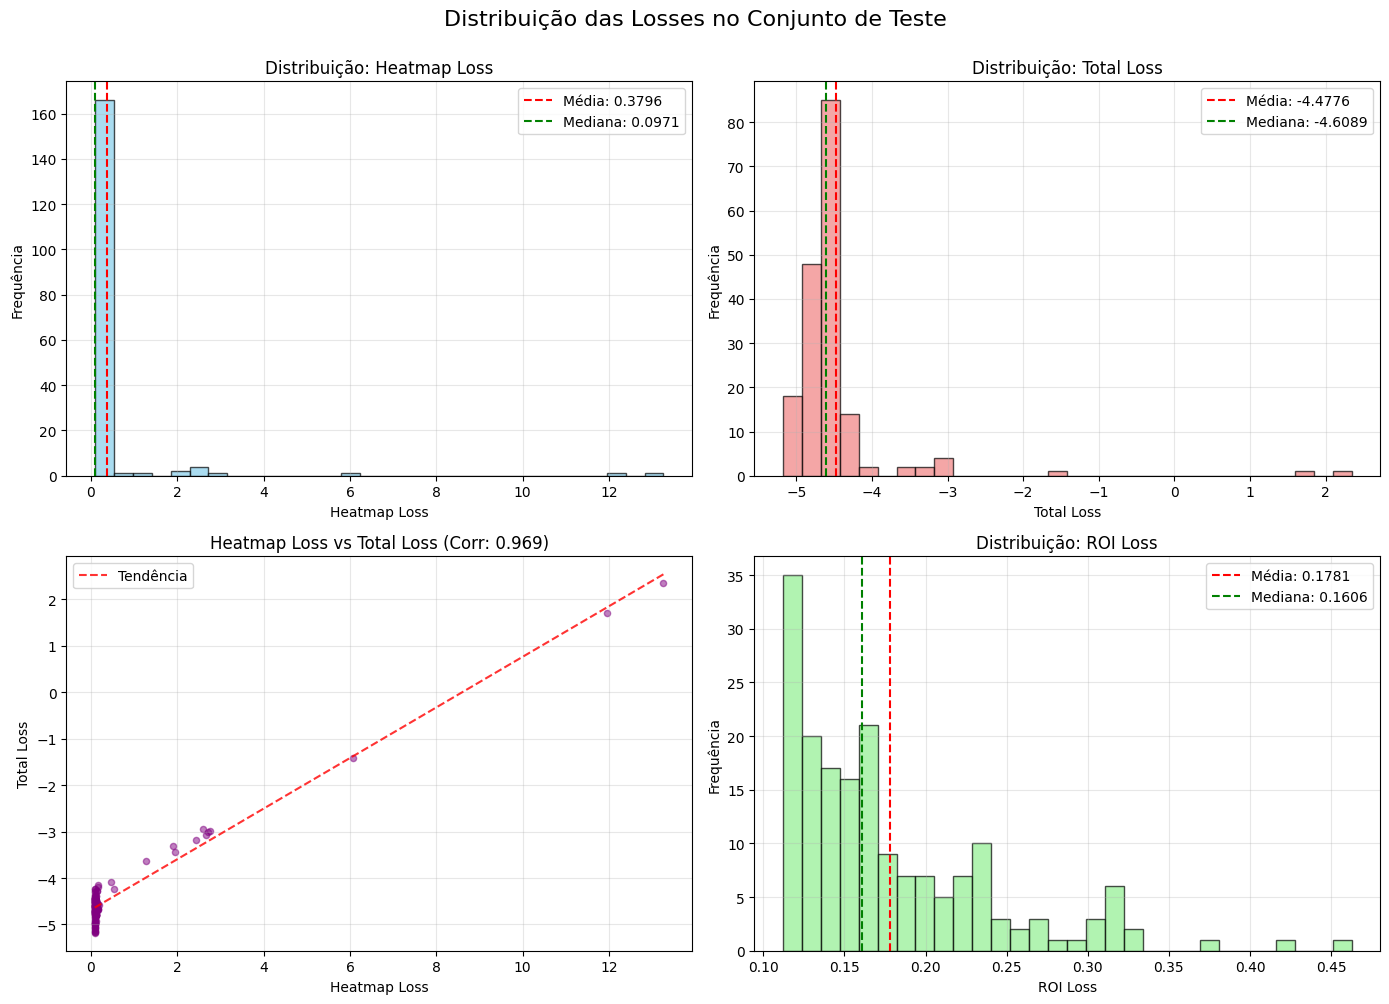

✓ Gráfico salvo: figs\unet\FocalMSEMaskedLoss_200ep\fold1\keypoint_analysis.png


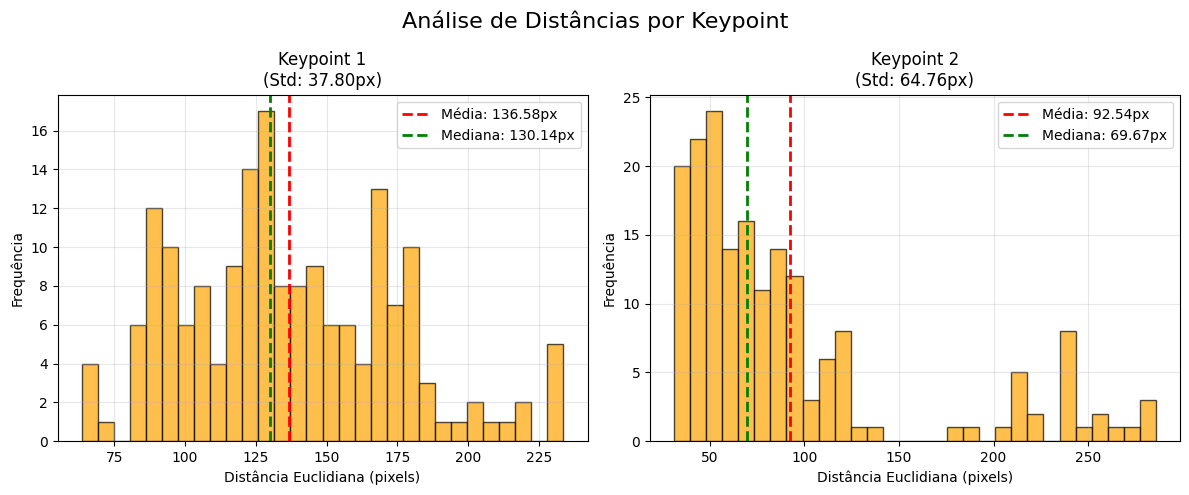


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\unet\FocalMSEMaskedLoss_200ep\fold1\predictions_by_distance_keypoint1.png


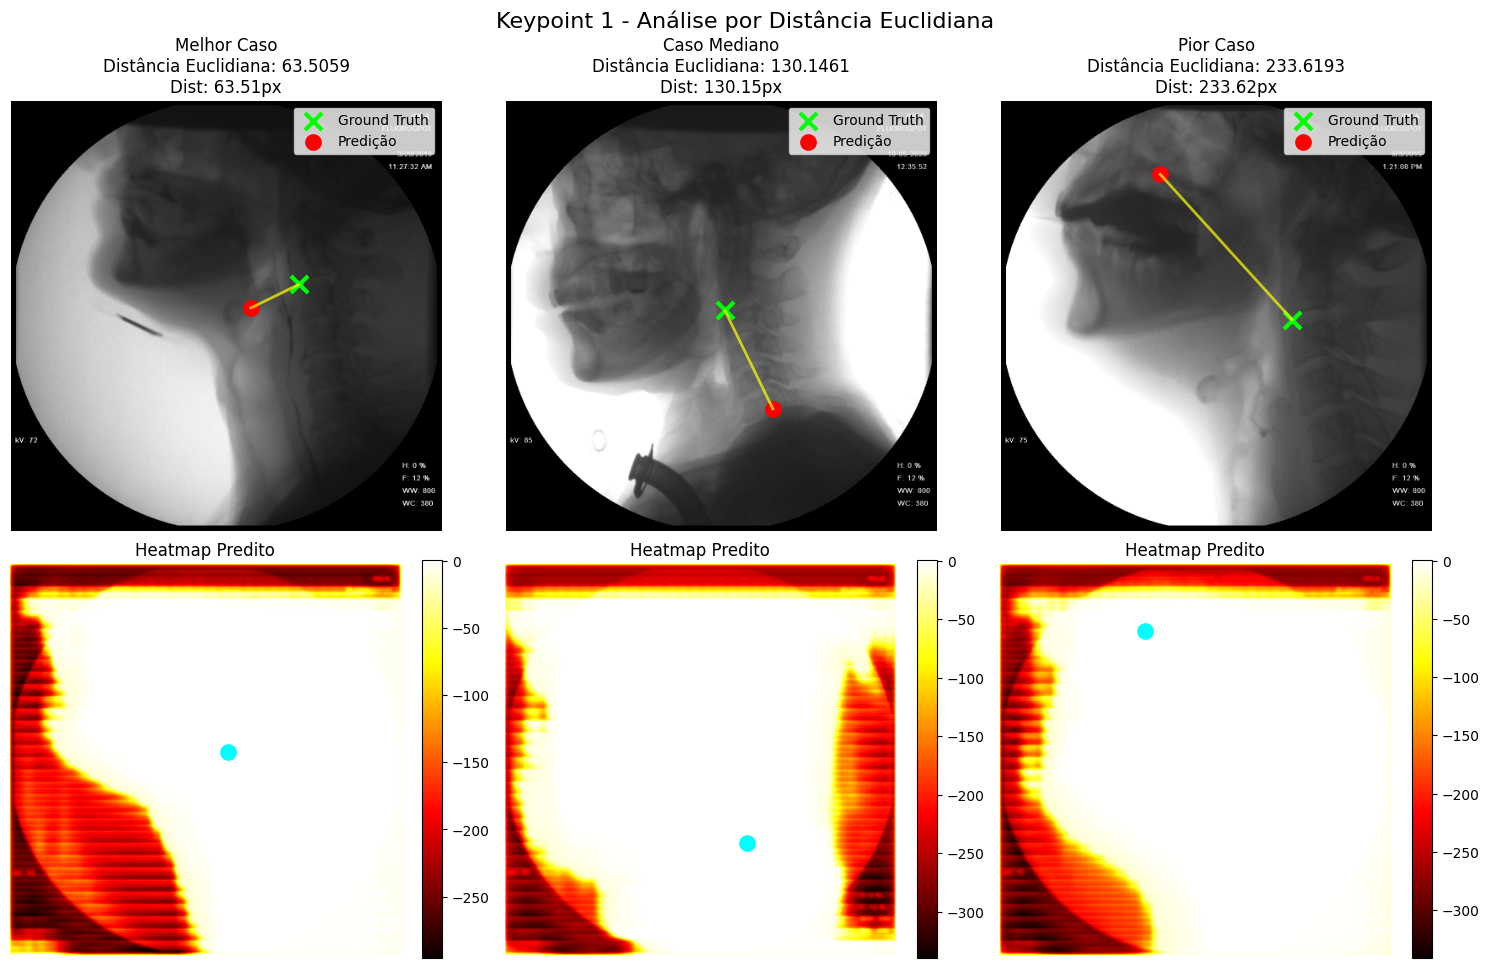


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\unet\FocalMSEMaskedLoss_200ep\fold1\predictions_by_distance_keypoint2.png


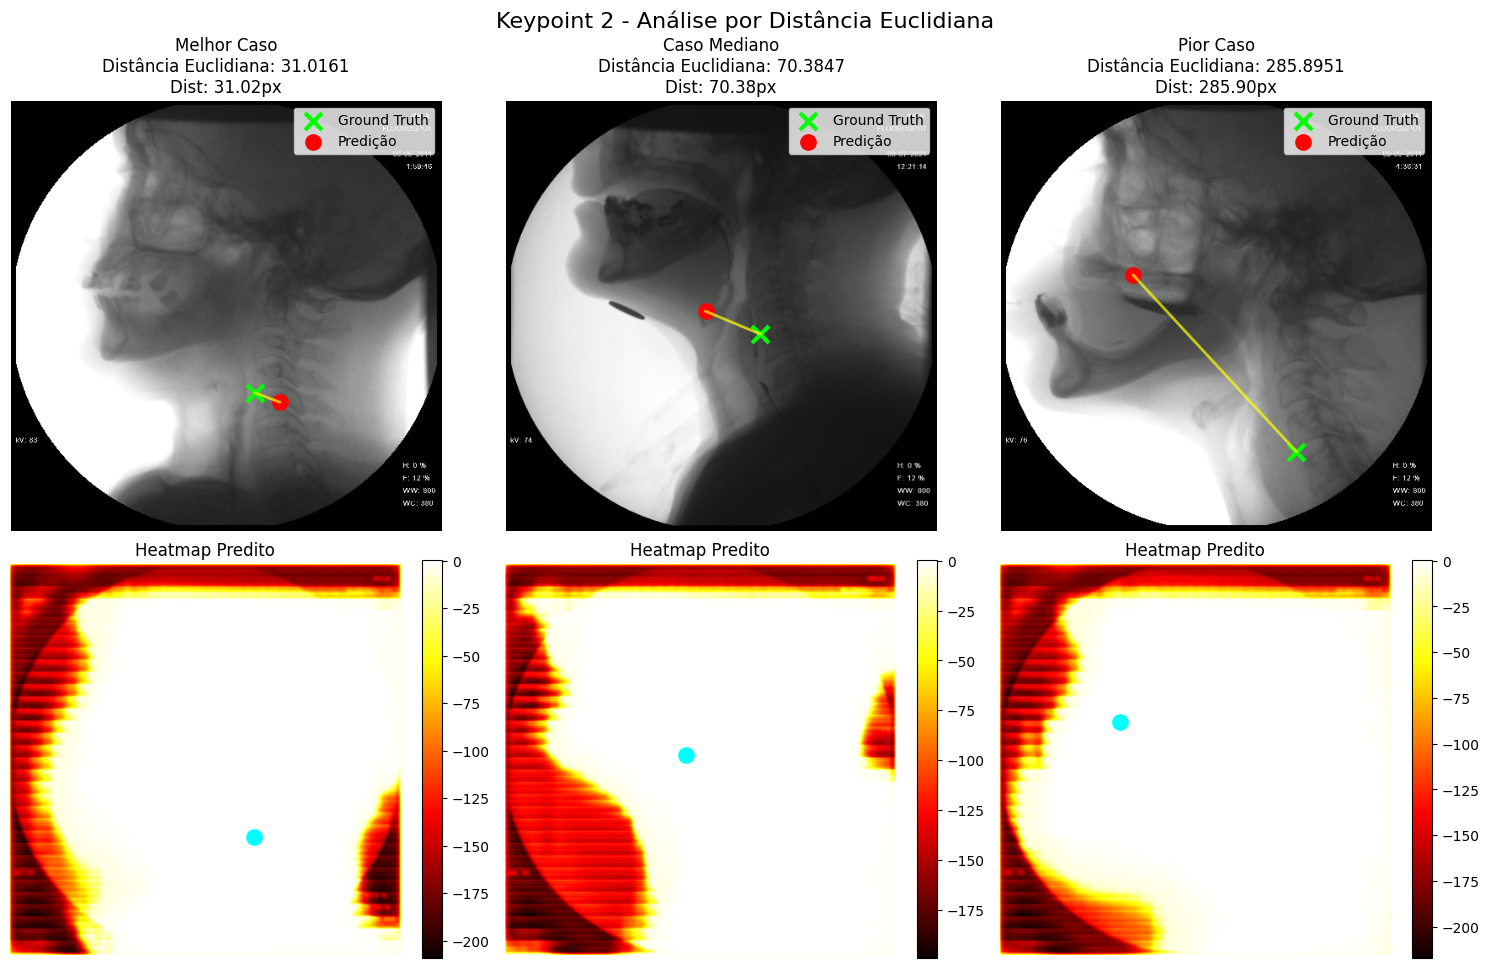


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\unet\FocalMSEMaskedLoss_200ep\fold1\predictions_by_loss_keypoint1.png


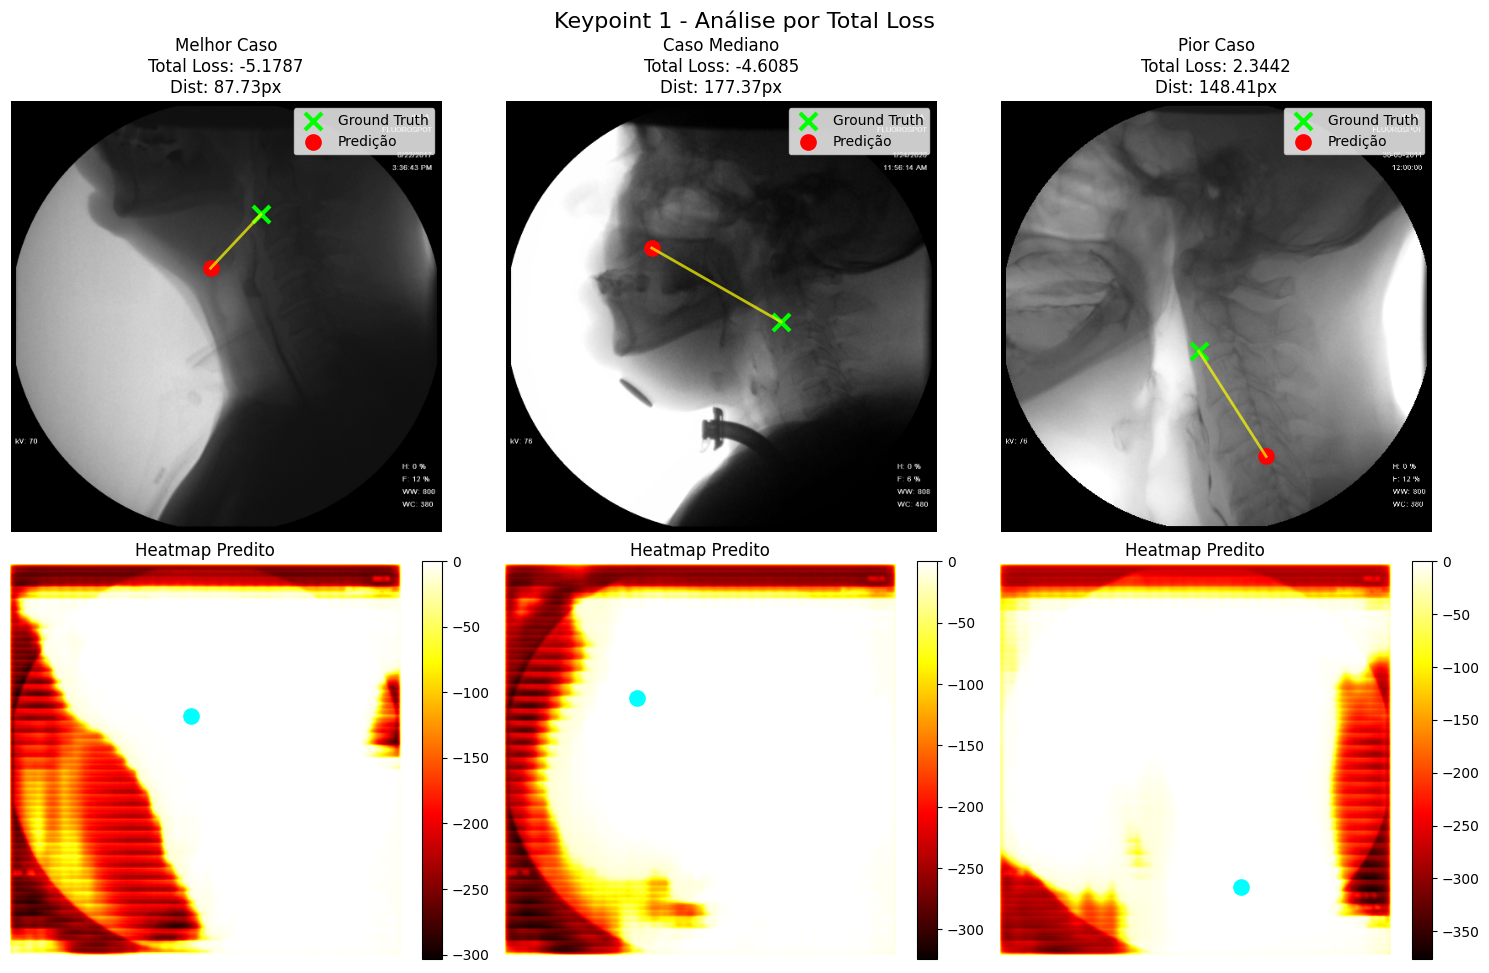


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\unet\FocalMSEMaskedLoss_200ep\fold1\predictions_by_loss_keypoint2.png


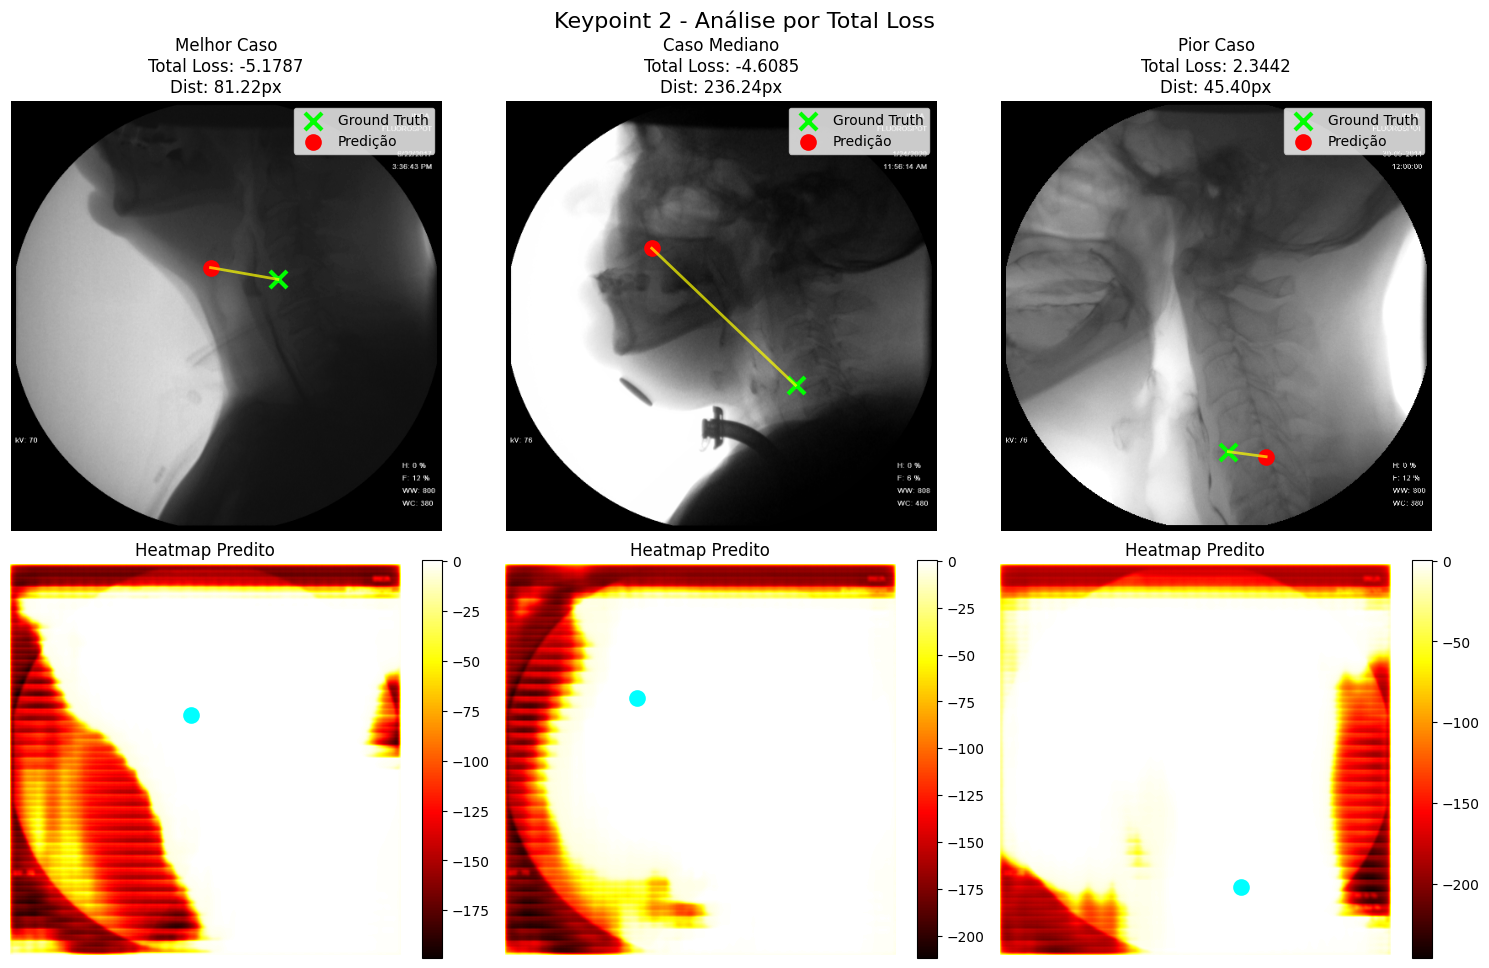

RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    -4.477596
Mediana:  -4.608875
Std:      0.816503
Min:      -5.178730
Max:      2.344229

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.379599
Mediana:  0.097057
Std:      1.453712

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.178128
Mediana:  0.160598
Std:      0.063900

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    136.58
Mediana:  130.14
Std:      37.80
Min:      63.51
Max: 

FileNotFoundError: [Errno 2] No such file or directory: 'data\\model_weights\\unet\\FocalMSEMaskedLoss_200ep\\fold_2_best.pth'

In [ ]:
# TESTE

# Conjunto de Teste
test_dataset = VFSSImageDataset(
    video_frame_df = df_test,
    output_dim = output_dim,
    transform = transform_puro,      # Sempre sem augmentation para o Teste, então deve ser deterministico
    offline_augmentation=False, # Sempre False para o teste
    sigma = sigma,
)

for fold_idx in range(len(list_df_folds)):

    # Carrega melhor modelo do fold 1
    checkpoint_path = f"data\\model_weights\\{model_name}\\fold_{fold_idx+1}_best.pth"
    
    # Executa avaliação completa
    results = evaluate_model_on_test(
        model_class=UNet,
        model_kwargs=model_kwargs,
        checkpoint_path=checkpoint_path,
        test_dataset=test_dataset,
        config=config,
        modify_input_fn=modify_input,
        output_dir=f"figs\\{model_name}\\fold{fold_idx+1}"
    )
    